# Tutorial 3: Overfitting and Normalization

Course: **Applied Deep Learning (ECE1553) - FALL 2026**
Instructor: **Dr. Ali Breyhi**
Tutorial: **Saleh Tabatabaei**

By the end of this tutorial you will be able to:
1. Produce an overfitted network and **diagnose** it with a validation set.
2. Fix it with **weight decay** and **dropout**.
3. Implement **BatchNorm**, **LayerNorm** and **data augmentation** in PyTorch.

In [18]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
from torchvision.transforms import v2          # image augmentation (Part 5)
from PIL import Image

from sklearn.datasets import make_classification, load_sample_image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Part 0 — Data: train / validation / test

A synthetic binary-classification task with 20 features (only 5 informative). Two choices make overfitting easy to see:
- a **small training set** (1,000 points), and
- **5 % label noise** (`flip_y=0.05`): those labels are random, so the only way to fit them is to memorize them.

Each split has one job:

| Split | Used for | How often |
|---|---|---|
| Train | fitting the weights | every step |
| Validation | diagnosing over/underfitting, choosing hyperparameters (epochs, λ, p, …) | every epoch |
| Test | one final, unbiased performance estimate | **once**, at the very end |

The split is made **once** and reused by every experiment, so all models are compared on identical data.

In [19]:
X, y = make_classification(n_samples=3000, n_features=20, n_informative=5, n_redundant=15,
                           flip_y=0.05, random_state=1)

# 1000 train / 1000 validation / 1000 test  (stratify = same class balance in every split)
X_train, X_rest, y_train, y_rest = train_test_split(X, y, train_size=1000, stratify=y, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=0)

# Normalize the INPUTS: fit the scaler on the training set only, then apply it to every split.
# (Fitting it on validation/test data would leak information about them into training.)
scaler = StandardScaler().fit(X_train)
X_train, X_val, X_test = [torch.tensor(scaler.transform(a), dtype=torch.float32) for a in (X_train, X_val, X_test)]
y_train, y_val, y_test = [torch.tensor(a, dtype=torch.float32).reshape(-1, 1) for a in (y_train, y_val, y_test)]

print(f"train {tuple(X_train.shape)}   val {tuple(X_val.shape)}   test {tuple(X_test.shape)}")

train (1000, 20)   val (1000, 20)   test (1000, 20)


## Part 1 — Overfitting and how to diagnose it

### 1.1 A high-capacity model
A deliberately oversized network (20 → 200 → 120 → 70 → 50 → 30 → 1, about 42k parameters) for only 1,000 training points.
Instead of writing a new class for every variant, one `MLP` class has switches for dropout and normalization, which we turn on in Parts 3 and 4. Each hidden block is:

`Linear → [BatchNorm | LayerNorm] → ReLU → [Dropout]`

The network outputs a **logit** (no `Sigmoid` layer). `nn.BCEWithLogitsLoss` applies the sigmoid inside the loss, which is numerically more stable than `Sigmoid` + `BCELoss`. We predict class 1 when the logit is > 0.

In [20]:
class MLP(nn.Module):
    '''Fully connected classifier. Hidden block: Linear -> [BatchNorm | LayerNorm] -> ReLU -> [Dropout]'''

    def __init__(self, in_dim=20, hidden=(200, 120, 70, 50, 30), p_drop=0.0, norm=None, seed=0):
        super().__init__()
        torch.manual_seed(seed)                  # every variant starts from the same initial weights
        layers = []
        for width in hidden:
            layers.append(nn.Linear(in_dim, width))
            if norm == "batch":
                layers.append(nn.BatchNorm1d(width))
            elif norm == "layer":
                layers.append(nn.LayerNorm(width))
            layers.append(nn.ReLU())
            if p_drop > 0:
                layers.append(nn.Dropout(p_drop))
            in_dim = width
        layers.append(nn.Linear(in_dim, 1))      # one logit per sample (the loss applies the sigmoid)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

### 1.2 Training loop
A standard mini-batch training loop, with the pieces that matter today made explicit:
- `model.train()` / `model.eval()`: **dropout and BatchNorm behave differently in the two modes**, so we switch explicitly.
- Evaluation runs under `torch.no_grad()` (no computation graph, so it is faster and uses less memory).
- Mini-batches are **reshuffled every epoch**.
- After every epoch we record loss and accuracy on the **training and validation** sets (never the test set).
- `weight_decay` (Part 2) and an optional `augment` function (Part 5) are already wired in.

In [21]:
loss_fn = nn.BCEWithLogitsLoss()   # sigmoid + binary cross-entropy in one numerically stable step


def evaluate(model, X, y):
    '''Loss and accuracy on (X, y) in eval mode: dropout off, BatchNorm uses its running statistics.'''
    model.eval()
    with torch.no_grad():
        logits = model(X)
        loss = loss_fn(logits, y).item()
        acc = ((logits > 0).float() == y).float().mean().item()
    return loss, acc


def train(model, n_epochs=100, batch_size=32, lr=1e-3, weight_decay=0.0, augment=None, seed=0):
    '''Mini-batch training on (X_train, y_train); records train/val loss and accuracy after every epoch.'''
    torch.manual_seed(seed)                     # reproducible shuffling, dropout masks and noise
    # note: AdamW's default weight_decay is 0.01, so we pass it explicitly (0 = no regularization)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(n_epochs):
        model.train()                           # dropout ON, BatchNorm uses batch statistics
        perm = torch.randperm(len(X_train))     # new mini-batch order every epoch
        for i in range(0, len(X_train), batch_size):
            idx = perm[i:i + batch_size]
            X_batch, y_batch = X_train[idx], y_train[idx]
            if augment is not None:             # Part 5: augment TRAINING batches only
                X_batch = augment(X_batch)

            loss = loss_fn(model(X_batch), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # end of epoch: evaluate on training and validation data (never on the test set!)
        for split, X_eval, y_eval in [("train", X_train, y_train), ("val", X_val, y_val)]:
            split_loss, split_acc = evaluate(model, X_eval, y_eval)
            history[f"{split}_loss"].append(split_loss)
            history[f"{split}_acc"].append(split_acc)
    return history

In [22]:
# ---- Helpers for running and comparing experiments (plotting code, no need to study it in class) ----
results, models = {}, {}      # experiment name -> training history / trained model


def experiment(name, model, **train_kwargs):
    '''Train `model` and keep the model and its history under `name`.'''
    start = time.perf_counter()
    results[name] = train(model, **train_kwargs)
    models[name] = model
    h = results[name]
    print(f"{name:<14} trained in {time.perf_counter() - start:4.1f}s | "
          f"final train loss {h['train_loss'][-1]:.3f} | final val loss {h['val_loss'][-1]:.3f}")


def summary(names=None):
    '''Final metrics of each experiment, plus the best validation loss and the epoch it occurred.'''
    rows = {}
    for name in names or results:
        h = results[name]
        rows[name] = {"train loss": h["train_loss"][-1], "val loss": h["val_loss"][-1],
                      "gap (val - train)": h["val_loss"][-1] - h["train_loss"][-1],
                      "train acc": h["train_acc"][-1], "val acc": h["val_acc"][-1],
                      "best val loss": min(h["val_loss"]), "best epoch": int(np.argmin(h["val_loss"]))}
    return pd.DataFrame.from_dict(rows, orient="index").round(3)


def plot_history(h, title):
    '''Loss and accuracy curves of one experiment; dashed line = epoch with the lowest validation loss.'''
    best = int(np.argmin(h["val_loss"]))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, label in [(axes[0], "loss", "BCE loss"), (axes[1], "acc", "accuracy")]:
        ax.plot(h[f"train_{metric}"], label="train")
        ax.plot(h[f"val_{metric}"], label="validation")
        ax.axvline(best, color="gray", ls="--", label=f"lowest val loss (epoch {best})")
        ax.set(xlabel="epoch", ylabel=label)
        ax.legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def compare(names, title):
    '''Solid = validation loss, dashed = training loss, one color per experiment.'''
    plt.figure(figsize=(9, 4))
    for name in names:
        line, = plt.plot(results[name]["val_loss"], label=name)
        plt.plot(results[name]["train_loss"], ls="--", color=line.get_color(), alpha=0.6)
    plt.xlabel("epoch")
    plt.ylabel("BCE loss")
    plt.title(f"{title}   (solid = validation, dashed = train)")
    plt.legend()
    plt.show()
    display(summary(names))

### 1.3 Train the baseline (no regularization)

MLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=120, bias=True)
    (3): ReLU()
    (4): Linear(in_features=120, out_features=70, bias=True)
    (5): ReLU()
    (6): Linear(in_features=70, out_features=50, bias=True)
    (7): ReLU()
    (8): Linear(in_features=50, out_features=30, bias=True)
    (9): ReLU()
    (10): Linear(in_features=30, out_features=1, bias=True)
  )
)
parameters: 41901 for 1000 training points
baseline       trained in  5.9s | final train loss 0.028 | final val loss 0.547


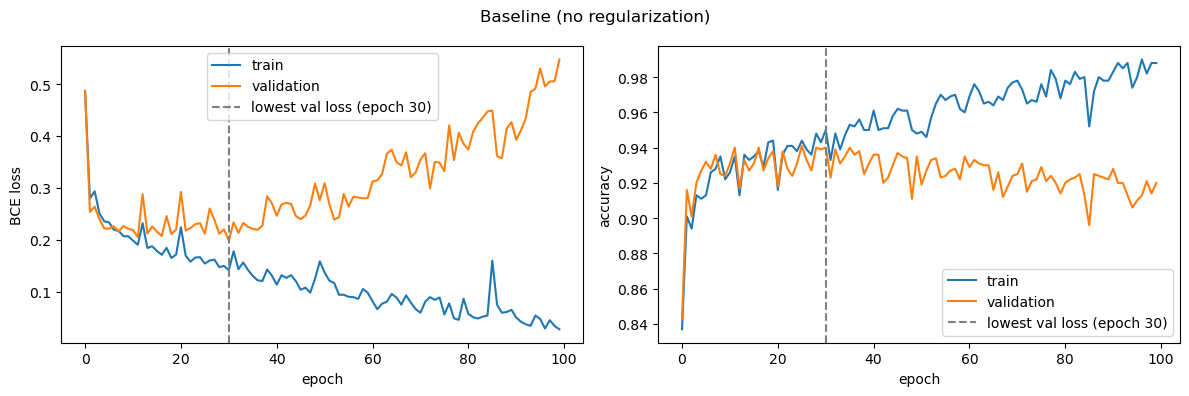

In [23]:
baseline = MLP()
print(baseline)
print("parameters:", sum(p.numel() for p in baseline.parameters()), "for", len(X_train), "training points")

experiment("baseline", baseline)
plot_history(results["baseline"], "Baseline (no regularization)")

### 1.4 Diagnosis: reading learning curves

| Training loss | Validation loss | Diagnosis | Typical remedies |
|---|---|---|---|
| high | high, close to training | **underfitting** | bigger model, train longer, less regularization |
| keeps falling | falls, then **rises**; the gap keeps growing | **overfitting** | more data / augmentation, weight decay, dropout, early stopping, smaller model |
| low | low, small gap | good fit | — |

The baseline is a textbook case of overfitting: the validation loss bottoms out early (dashed line) and then climbs, while the training loss keeps heading towards zero.
The simplest remedy is **early stopping**: keep the weights from the epoch with the lowest validation loss.

**Discuss**

1. Training accuracy climbs towards 100 %. Why is that suspicious for this dataset?
   <details><summary>Answer</summary>5 % of the labels were assigned at random, so even a perfect classifier cannot get much above ~97.5 %. Training accuracy beyond that means the network has memorized noisy labels.</details>
2. The validation *loss* gets much worse, but validation *accuracy* drops only a little. Why?
   <details><summary>Answer</summary>The overfitted network becomes over-confident. Most predictions stay correct, but the wrong ones are made with probabilities close to 0 or 1, and cross-entropy punishes confident mistakes heavily. Loss is the more sensitive overfitting signal.</details>
3. Why not use the test set to pick the best epoch?
   <details><summary>Answer</summary>Every decision made with a dataset makes that dataset's score optimistic. The validation set is "spent" on decisions; the test set stays untouched so the final number is unbiased.</details>

## Part 2 — Fix 1: Weight decay (L2 regularization)

Penalize large weights by adding $\frac{\lambda}{2}\lVert w\rVert^2$ to the loss. A gradient step then becomes

$$w \leftarrow w - \eta\,(\nabla L + \lambda w) = \underbrace{(1-\eta\lambda)\,w}_{\text{decay}} - \eta\,\nabla L$$

so every step shrinks all weights a little towards zero, and only weights the data keeps pushing stay large. Smaller weights give a smoother function that cannot memorize individual points as easily.

In PyTorch it is a single optimizer argument: `torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=λ)`.

> **Adam vs AdamW.** `Adam(weight_decay=λ)` adds $\lambda w$ to the gradient, which Adam's adaptive scaling then distorts. `AdamW` applies the decay $(1-\eta\lambda)\,w$ directly ("decoupled weight decay", Loshchilov & Hutter, 2019) and is the recommended choice.
> Because the shrink per step is $\eta\lambda = 10^{-3}\lambda$, our short 100-epoch runs need larger λ values than the 0.01–0.1 common in long trainings.

λ is a hyperparameter, so we **choose it on the validation set**:

wd=0.1         trained in  5.7s | final train loss 0.059 | final val loss 0.327
wd=1.0         trained in  5.8s | final train loss 0.160 | final val loss 0.204
wd=10.0        trained in  5.8s | final train loss 0.302 | final val loss 0.280


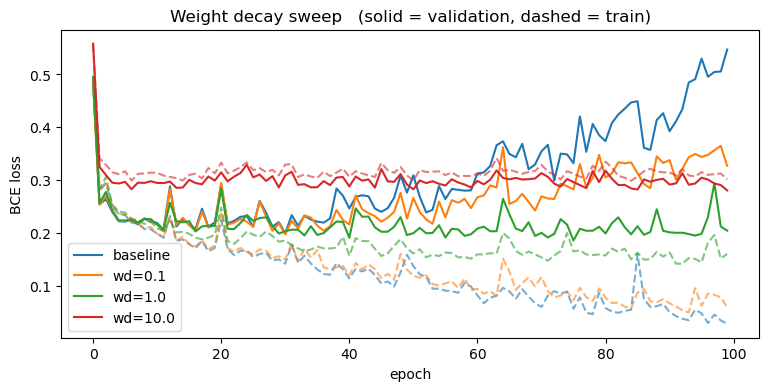

,train loss,val loss,gap (val - train),train acc,val acc,best val loss,best epoch
baseline,0.028,0.547,0.519,0.988,0.920,0.199,30
wd=0.1,0.059,0.327,0.268,0.977,0.926,0.197,30
wd=1.0,0.160,0.204,0.044,0.942,0.935,0.185,75
wd=10.0,0.302,0.280,-0.021,0.896,0.921,0.280,99


In [24]:
for wd in [0.1, 1.0, 10.0]:
    experiment(f"wd={wd}", MLP(), weight_decay=wd)

compare(["baseline", "wd=0.1", "wd=1.0", "wd=10.0"], "Weight decay sweep")

In [25]:
def weight_norm(model):
    '''L2 norm of all weight matrices (biases excluded).'''
    with torch.no_grad():
        return torch.sqrt(sum((p ** 2).sum() for n, p in model.named_parameters() if n.endswith("weight"))).item()


for name in ["baseline", "wd=0.1", "wd=1.0", "wd=10.0"]:
    print(f"{name:<9} ||W|| = {weight_norm(models[name]):6.2f}")

baseline  ||W|| =  20.57
wd=0.1    ||W|| =  16.68
wd=1.0    ||W|| =   8.09
wd=10.0   ||W|| =   6.21


**What to look for:** as λ grows, the weights shrink and the train/validation gap closes. Too little decay (λ = 0.1) still overfits; too much (λ = 10) **underfits**, meaning the training loss itself stays high. Regularization strength is a dial between overfitting and underfitting, and the validation loss tells you where to set it.

## Part 3 — Fix 2: Dropout

During training, `nn.Dropout(p)` sets each activation to zero with probability `p` and scales the survivors by $1/(1-p)$, so the expected activation is unchanged ("inverted dropout"). Every mini-batch trains a different random sub-network, so units cannot rely on specific partners, and the full network acts like an ensemble of sub-networks at test time.

> PyTorch's `p` is the probability of **dropping** a unit; some slides use the probability of *keeping* it instead.

Dropout is only active in training mode; `model.eval()` switches it off:

In [26]:
dropout = nn.Dropout(p=0.5)
x = torch.ones(2, 8)

dropout.train()
print("train mode:\n", dropout(x))   # about half the entries zeroed, survivors scaled to 1/(1-0.5) = 2
dropout.eval()
print("eval mode:\n", dropout(x))    # identity

train mode:
 tensor([[0., 0., 2., 2., 2., 2., 0., 2.],
        [0., 0., 2., 0., 2., 2., 0., 2.]])
eval mode:
 tensor([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])


Now add dropout with p = 0.3 after every hidden ReLU:

Sequential(
  (0): Linear(in_features=20, out_features=200, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
)
dropout p=0.3  trained in  6.8s | final train loss 0.112 | final val loss 0.246


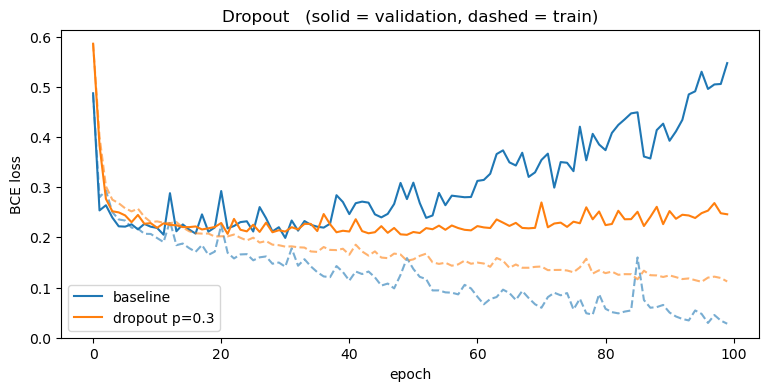

,train loss,val loss,gap (val - train),train acc,val acc,best val loss,best epoch
baseline,0.028,0.547,0.519,0.988,0.920,0.199,30
dropout p=0.3,0.112,0.246,0.134,0.963,0.941,0.205,49


In [27]:
print(MLP(p_drop=0.3).net[:3])        # first hidden block: Linear -> ReLU -> Dropout

experiment("dropout p=0.3", MLP(p_drop=0.3))
compare(["baseline", "dropout p=0.3"], "Dropout")

**What to look for:** the training loss falls more slowly (the network has to cope with random noise), but the validation loss no longer climbs and the gap stays small.
Note that our recorded training loss is measured in `eval()` mode with dropout off, so the two curves are directly comparable.

## Part 4 — Normalization: BatchNorm and LayerNorm

Normalization layers re-center and re-scale activations inside the network, so every layer receives inputs on a stable scale. The main benefit is easier **optimization** (faster, less sensitive to initialization and learning rate); regularization is at most a side effect.

Both compute $\hat h = \dfrac{h-\mu}{\sqrt{\sigma^2+\epsilon}}$ followed by a learnable scale and shift $\gamma \hat h + \beta$. They differ only in **which numbers** $\mu$ and $\sigma$ are computed over:

| | `nn.BatchNorm1d(d)` | `nn.LayerNorm(d)` |
|---|---|---|
| statistics over | the **batch**, separately for each feature (columns) | the **features**, separately for each sample (rows) |
| train vs. eval | different: batch statistics vs. running averages | identical |
| batch of size 1 | fails in training mode | fine |
| typical use | CNNs, MLPs with reasonably large batches | Transformers, RNNs, small or variable batches |

In [28]:
torch.manual_seed(0)
h = 3 * torch.randn(4, 5) + 10        # a batch: 4 samples x 5 features, mean ≈ 10, std ≈ 3
bn, ln = nn.BatchNorm1d(5), nn.LayerNorm(5)

eps = 1e-5
# normalize each column (BatchNorm) / each row (LayerNorm) by hand
manual_bn = (h - h.mean(dim=0)) / torch.sqrt(h.var(dim=0, unbiased=False) + eps)
manual_ln = (h - h.mean(dim=1, keepdim=True)) / torch.sqrt(h.var(dim=1, unbiased=False, keepdim=True) + eps)

print("BatchNorm == normalize every column (feature):", torch.allclose(bn(h), manual_bn, atol=1e-5))
print("LayerNorm == normalize every row (sample):    ", torch.allclose(ln(h), manual_ln, atol=1e-5))

BatchNorm == normalize every column (feature): True
LayerNorm == normalize every row (sample):     True


In [29]:
# In train mode BatchNorm also updates running averages of the batch statistics.
# (Exponential moving average with momentum 0.1: after one batch it is only 0.1 x the batch mean.)
print("running mean:", bn.running_mean)

# In eval mode it uses those running averages, so it can normalize a single sample.
# The output is not ≈ 0 yet: the running averages need many training batches to converge.
bn.eval()
print("BN, eval mode, 1 sample: ", bn(h[:1]).detach())

# In train mode it needs a batch of more than one sample to compute statistics.
bn.train()
try:
    bn(h[:1])
except ValueError as err:
    print("BN, train mode, 1 sample:", err)

# LayerNorm never looks at other samples, so the batch size doesn't matter.
print("LN, 1 sample:            ", ln(h[:1]).detach())

running mean: tensor([0.8439, 0.9778, 1.3188, 1.2719, 1.1081])
BN, eval mode, 1 sample:  tensor([[ 3.6403,  4.3880,  6.1761,  5.2548, 10.0602]])
BN, train mode, 1 sample: Expected more than 1 value per channel when training, got input size torch.Size([1, 5])
LN, 1 sample:             tensor([[-1.0107, -1.0518,  0.3439,  0.0602,  1.6584]])


Now put them in the model, between each linear layer and its activation.

> **Practical tips**
> - With BatchNorm, a last mini-batch of size 1 crashes training; `DataLoader(..., drop_last=True)` avoids this (1000 / 32 leaves a last batch of 8, so we are fine).
> - A `Linear` layer followed by BatchNorm does not need its own bias (`bias=False`): BatchNorm's β does the same job.
> - Forgetting `model.eval()` is the most common BatchNorm bug: evaluation results then depend on which samples share a batch.

batchnorm      trained in 11.9s | final train loss 0.100 | final val loss 0.240
layernorm      trained in  8.5s | final train loss 0.047 | final val loss 0.293


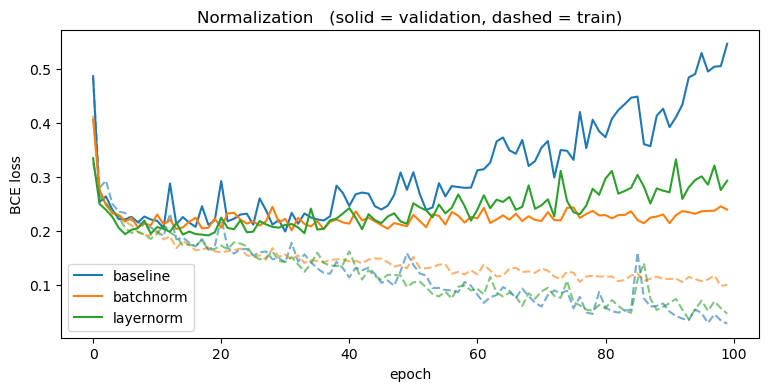

,train loss,val loss,gap (val - train),train acc,val acc,best val loss,best epoch
baseline,0.028,0.547,0.519,0.988,0.920,0.199,30
batchnorm,0.100,0.240,0.140,0.966,0.932,0.201,31
layernorm,0.047,0.293,0.247,0.981,0.922,0.192,18


Sequential(
  (0): Linear(in_features=20, out_features=200, bias=True)
  (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
)
batchnorm      trained in 11.6s | final train loss 0.100 | final val loss 0.240
layernorm      trained in  8.7s | final train loss 0.047 | final val loss 0.293


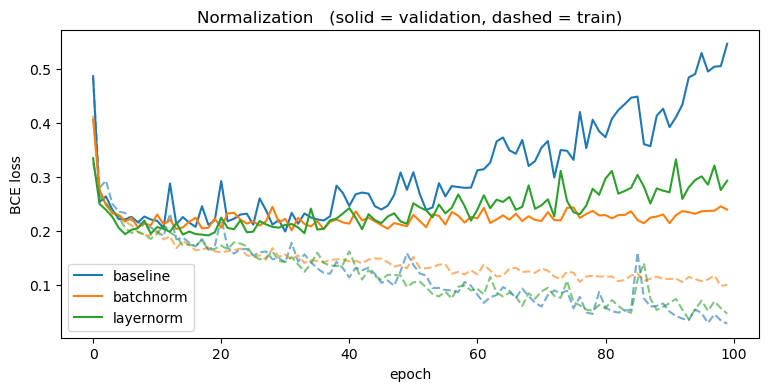

,train loss,val loss,gap (val - train),train acc,val acc,best val loss,best epoch
baseline,0.028,0.547,0.519,0.988,0.920,0.199,30
batchnorm,0.100,0.240,0.140,0.966,0.932,0.201,31
layernorm,0.047,0.293,0.247,0.981,0.922,0.192,18


In [30]:
print(MLP(norm="batch").net[:3])      # first hidden block: Linear -> BatchNorm1d -> ReLU

experiment("batchnorm", MLP(norm="batch"))
experiment("layernorm", MLP(norm="layer"))
compare(["baseline", "batchnorm", "layernorm"], "Normalization")

**What to look for**
- In the first epochs the normalized networks typically reduce the training loss a little faster. On a 5-layer MLP trained with Adam the speed-up is modest; in much deeper networks it can decide whether training works at all.
- BatchNorm often overfits less than the baseline: each sample is normalized with the statistics of a *random* mini-batch, which adds noise and acts as a mild regularizer. LayerNorm uses per-sample statistics, adds no such noise and regularizes less.
- Normalization does not replace weight decay or dropout; in practice they are combined.

## Part 5 — Data augmentation

The most reliable cure for overfitting is more data. Augmentation manufactures it by applying random, **label-preserving** transformations to the training inputs on the fly, so the network sees a slightly different version of every example in every epoch.

- Augment **training data only**; validation and test data stay untouched.
- A transformation is valid only if it keeps the label: a mirrored cat is still a cat, but a "6" rotated by 180° becomes a "9".
- Each augmentation encodes an invariance you *know* the task has.

### 5.1 Images
`torchvision.transforms.v2` provides the standard image augmentations. Here they are applied to a photo that ships with scikit-learn:

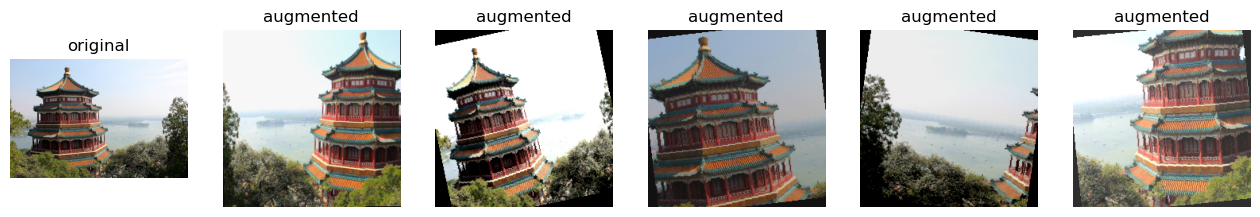

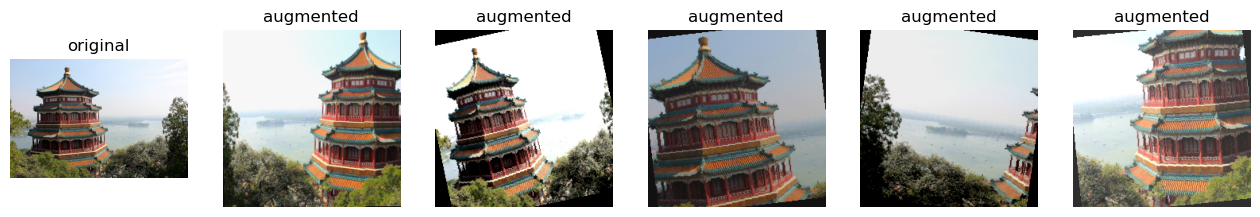

In [31]:
photo = Image.fromarray(load_sample_image("china.jpg"))

augment_image = v2.Compose([
    v2.RandomResizedCrop(size=224, scale=(0.4, 1.0)),                # random crop, resized ("zoom")
    v2.RandomHorizontalFlip(p=0.5),                                   # mirror
    v2.RandomRotation(degrees=15),                                    # small tilt
    v2.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),     # lighting and color changes
])

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(photo)
axes[0].set_title("original")
for ax in axes[1:]:
    ax.imshow(augment_image(photo))     # a new random version on every call
    ax.set_title("augmented")
for ax in axes:
    ax.axis("off")
plt.show()

In a real pipeline the random transform is attached to the **training** dataset only, e.g. for CIFAR-10:

```python
train_tf = v2.Compose([v2.RandomCrop(32, padding=4), v2.RandomHorizontalFlip(),
                       v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
test_tf  = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])   # no randomness

train_set = torchvision.datasets.CIFAR10("data", train=True,  transform=train_tf, download=True)
test_set  = torchvision.datasets.CIFAR10("data", train=False, transform=test_tf,  download=True)
```

### 5.2 Tabular data: noise injection
Our 20 features have no natural "flip" or "crop", but a common tabular augmentation is to add a little Gaussian noise to the standardized inputs, based on the assumption that points very close to a training example share its label. `train()` applies `augment` to each **training** mini-batch only.

noise σ=0.3    trained in  5.9s | final train loss 0.124 | final val loss 0.256


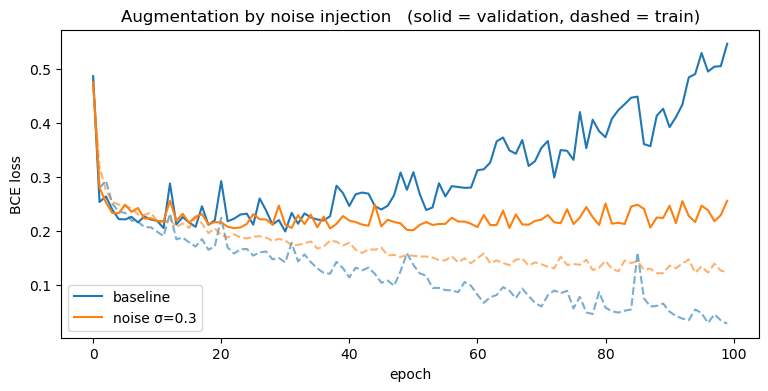

,train loss,val loss,gap (val - train),train acc,val acc,best val loss,best epoch
baseline,0.028,0.547,0.519,0.988,0.920,0.199,30
noise σ=0.3,0.124,0.256,0.132,0.953,0.926,0.201,50


noise σ=0.3    trained in  6.1s | final train loss 0.124 | final val loss 0.256


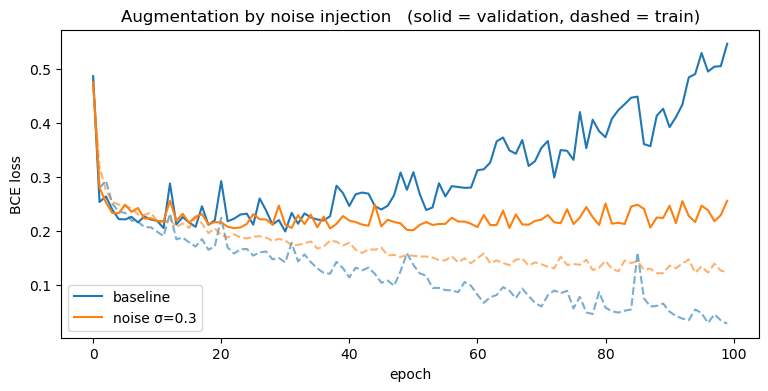

,train loss,val loss,gap (val - train),train acc,val acc,best val loss,best epoch
baseline,0.028,0.547,0.519,0.988,0.920,0.199,30
noise σ=0.3,0.124,0.256,0.132,0.953,0.926,0.201,50


In [32]:
def add_gaussian_noise(x, sigma=0.3):
    '''Fresh noise on every call, so every epoch sees a new version of each training point.'''
    return x + sigma * torch.randn_like(x)


experiment("noise σ=0.3", MLP(), augment=add_gaussian_noise)
compare(["baseline", "noise σ=0.3"], "Augmentation by noise injection")

**What to look for:** the gap shrinks much like with weight decay. That is no coincidence: training with small input noise is approximately equivalent to an L2-type (Tikhonov) penalty (Bishop, 1995).

## Part 6 — Wrap-up: select on validation, report on test

All decisions (method, λ, p, σ) are made with the validation set. Only the selected model is evaluated on the test set, once.
Since we did not use early stopping, we select on the **final** validation loss, which belongs to the weights we actually kept.

In [33]:
table = summary().sort_values("val loss")
display(table)

,train loss,val loss,gap (val - train),train acc,val acc,best val loss,best epoch
wd=1.0,0.160,0.204,0.044,0.942,0.935,0.185,75
batchnorm,0.100,0.240,0.140,0.966,0.932,0.201,31
dropout p=0.3,0.112,0.246,0.134,0.963,0.941,0.205,49
noise σ=0.3,0.124,0.256,0.132,0.953,0.926,0.201,50
wd=10.0,0.302,0.280,-0.021,0.896,0.921,0.280,99
layernorm,0.047,0.293,0.247,0.981,0.922,0.192,18
wd=0.1,0.059,0.327,0.268,0.977,0.926,0.197,30
baseline,0.028,0.547,0.519,0.988,0.920,0.199,30


,train loss,val loss,gap (val - train),train acc,val acc,best val loss,best epoch
wd=1.0,0.160,0.204,0.044,0.942,0.935,0.185,75
batchnorm,0.100,0.240,0.140,0.966,0.932,0.201,31
dropout p=0.3,0.112,0.246,0.134,0.963,0.941,0.205,49
noise σ=0.3,0.124,0.256,0.132,0.953,0.926,0.201,50
wd=10.0,0.302,0.280,-0.021,0.896,0.921,0.280,99
layernorm,0.047,0.293,0.247,0.981,0.922,0.192,18
wd=0.1,0.059,0.327,0.268,0.977,0.926,0.197,30
baseline,0.028,0.547,0.519,0.988,0.920,0.199,30


In [34]:
chosen = table.index[0]               # lowest final validation loss
test_loss, test_acc = evaluate(models[chosen], X_test, y_test)

print(f"selected on validation: {chosen}")
print(f"validation: loss {results[chosen]['val_loss'][-1]:.3f} | acc {results[chosen]['val_acc'][-1]:.3f}")
print(f"test:       loss {test_loss:.3f} | acc {test_acc:.3f}")

selected on validation: wd=1.0
validation: loss 0.204 | acc 0.935
test:       loss 0.286 | acc 0.895
selected on validation: wd=1.0
validation: loss 0.204 | acc 0.935
test:       loss 0.286 | acc 0.895


If validation did its job, the test numbers are close to the validation numbers.

## Key takeaways
- **Diagnose with a validation set.** A growing gap between training and validation loss means overfitting; high loss on both means underfitting.
- **Weight decay** (`AdamW(..., weight_decay=λ)`) shrinks the weights every step. Tune λ on validation: too much underfits.
- **Dropout** (`nn.Dropout(p)`) trains random sub-networks and is switched off automatically by `model.eval()`.
- **BatchNorm** normalizes each feature over the batch (train ≠ eval, needs batches larger than 1); **LayerNorm** normalizes each sample over its features (train = eval). Both mainly help optimization.
- **Augmentation** adds label-preserving variations of the training data, applied to the training set only.
- Make every decision on validation and touch the test set once.


## Teke-home exercises (optional)
1. **L1 regularization.** PyTorch has no built-in L1 option, so add the penalty to the loss inside `train()`:
   ```python
   loss = loss_fn(model(X_batch), y_batch) + l1_lambda * sum(p.abs().sum() for p in model.parameters())
   ```
   Try `l1_lambda = 1e-4`. Compared with weight decay, what fraction of weights ends up near zero (e.g. `|w| < 1e-3`)? Why?
2. **Early stopping.** Modify `train()` to save `copy.deepcopy(model.state_dict())` whenever the validation loss improves, and restore it at the end. How does the baseline change?
3. **Combine.** Train `MLP(p_drop=0.3, norm="batch")` with `weight_decay=1.0`. Is more regularization always better? Let the validation set decide.
4. **Capacity.** Train `MLP(hidden=(16,))` and `MLP(hidden=(2,))`. Which row of the diagnosis table does each one match?